<a href="https://colab.research.google.com/github/Kunal355/Uber-trip-Analysis/blob/project/Uber_Trip_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Importing Necessary Libraries ---

import warnings
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")

# --- 2. Data Loading and Preparation (for Google Colab) ---


# Get all uber rides raw data
files = []
# The path to the uploaded files in Google Colab is typically './'
data_path = './'
for dirname, _, filenames in os.walk(data_path):
    for filename in filenames:
        # We only want the 2014 raw Uber data files for this project
        if "uber-raw-data" in filename and "14" in filename and filename.endswith('.csv'):
            files.append(os.path.join(dirname, filename))

# Read and concatenate all CSV files from April to September 2014
dataframes = [pd.read_csv(file) for file in files]
data = pd.concat(dataframes, ignore_index=True)

data.info()
data.head()

# Now make sure the date column is set to datetime
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%m/%d/%Y %H:%M:%S')

# Group by hour and count occurrences of 'Base'
data.set_index('Date/Time', inplace=True)
hourly_counts = data['Base'].resample('h').count()

# Convert the series to a dataframe and rename columns for clarity
data = hourly_counts.reset_index()
data.columns = ['Date', 'Count']
data.set_index('Date', inplace=True)



--- Data Head ---
          Date/Time      Lat      Lon    Base
0  4/1/2014 0:11:00  40.7690 -73.9549  B02512
1  4/1/2014 0:17:00  40.7267 -74.0345  B02512
2  4/1/2014 0:21:00  40.7316 -73.9873  B02512
3  4/1/2014 0:28:00  40.7588 -73.9776  B02512
4  4/1/2014 0:33:00  40.7594 -73.9722  B02512

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4534327 entries, 0 to 4534326
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date/Time  object 
 1   Lat        float64
 2   Lon        float64
 3   Base       object 
dtypes: float64(2), object(2)
memory usage: 138.4+ MB
None


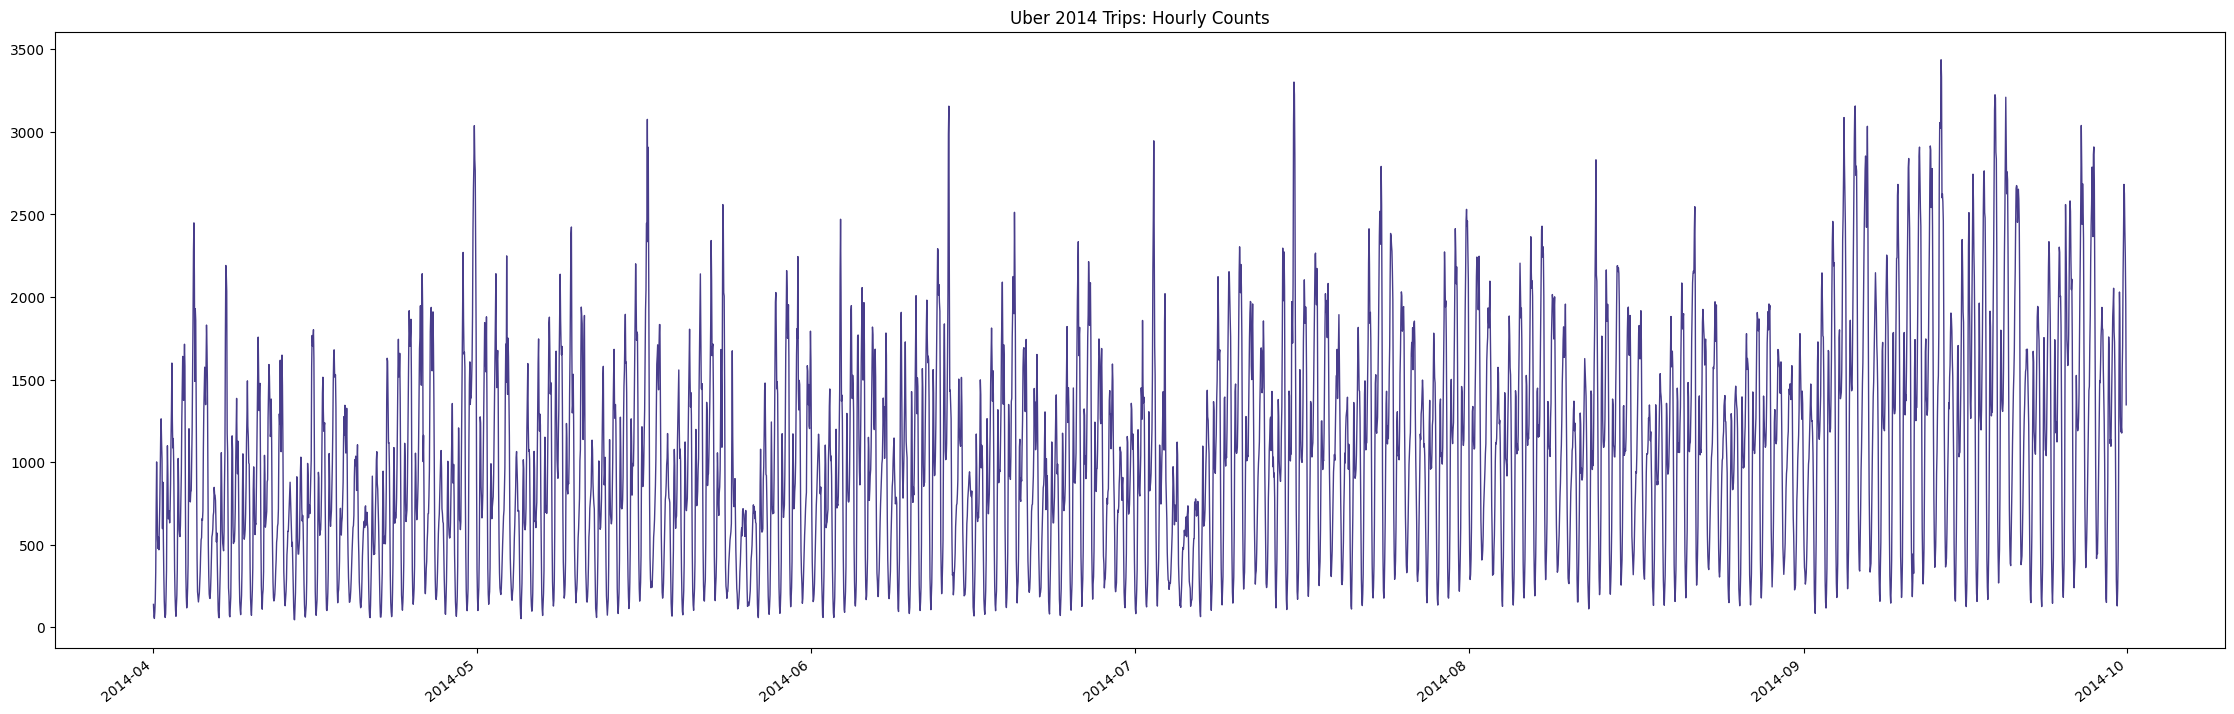

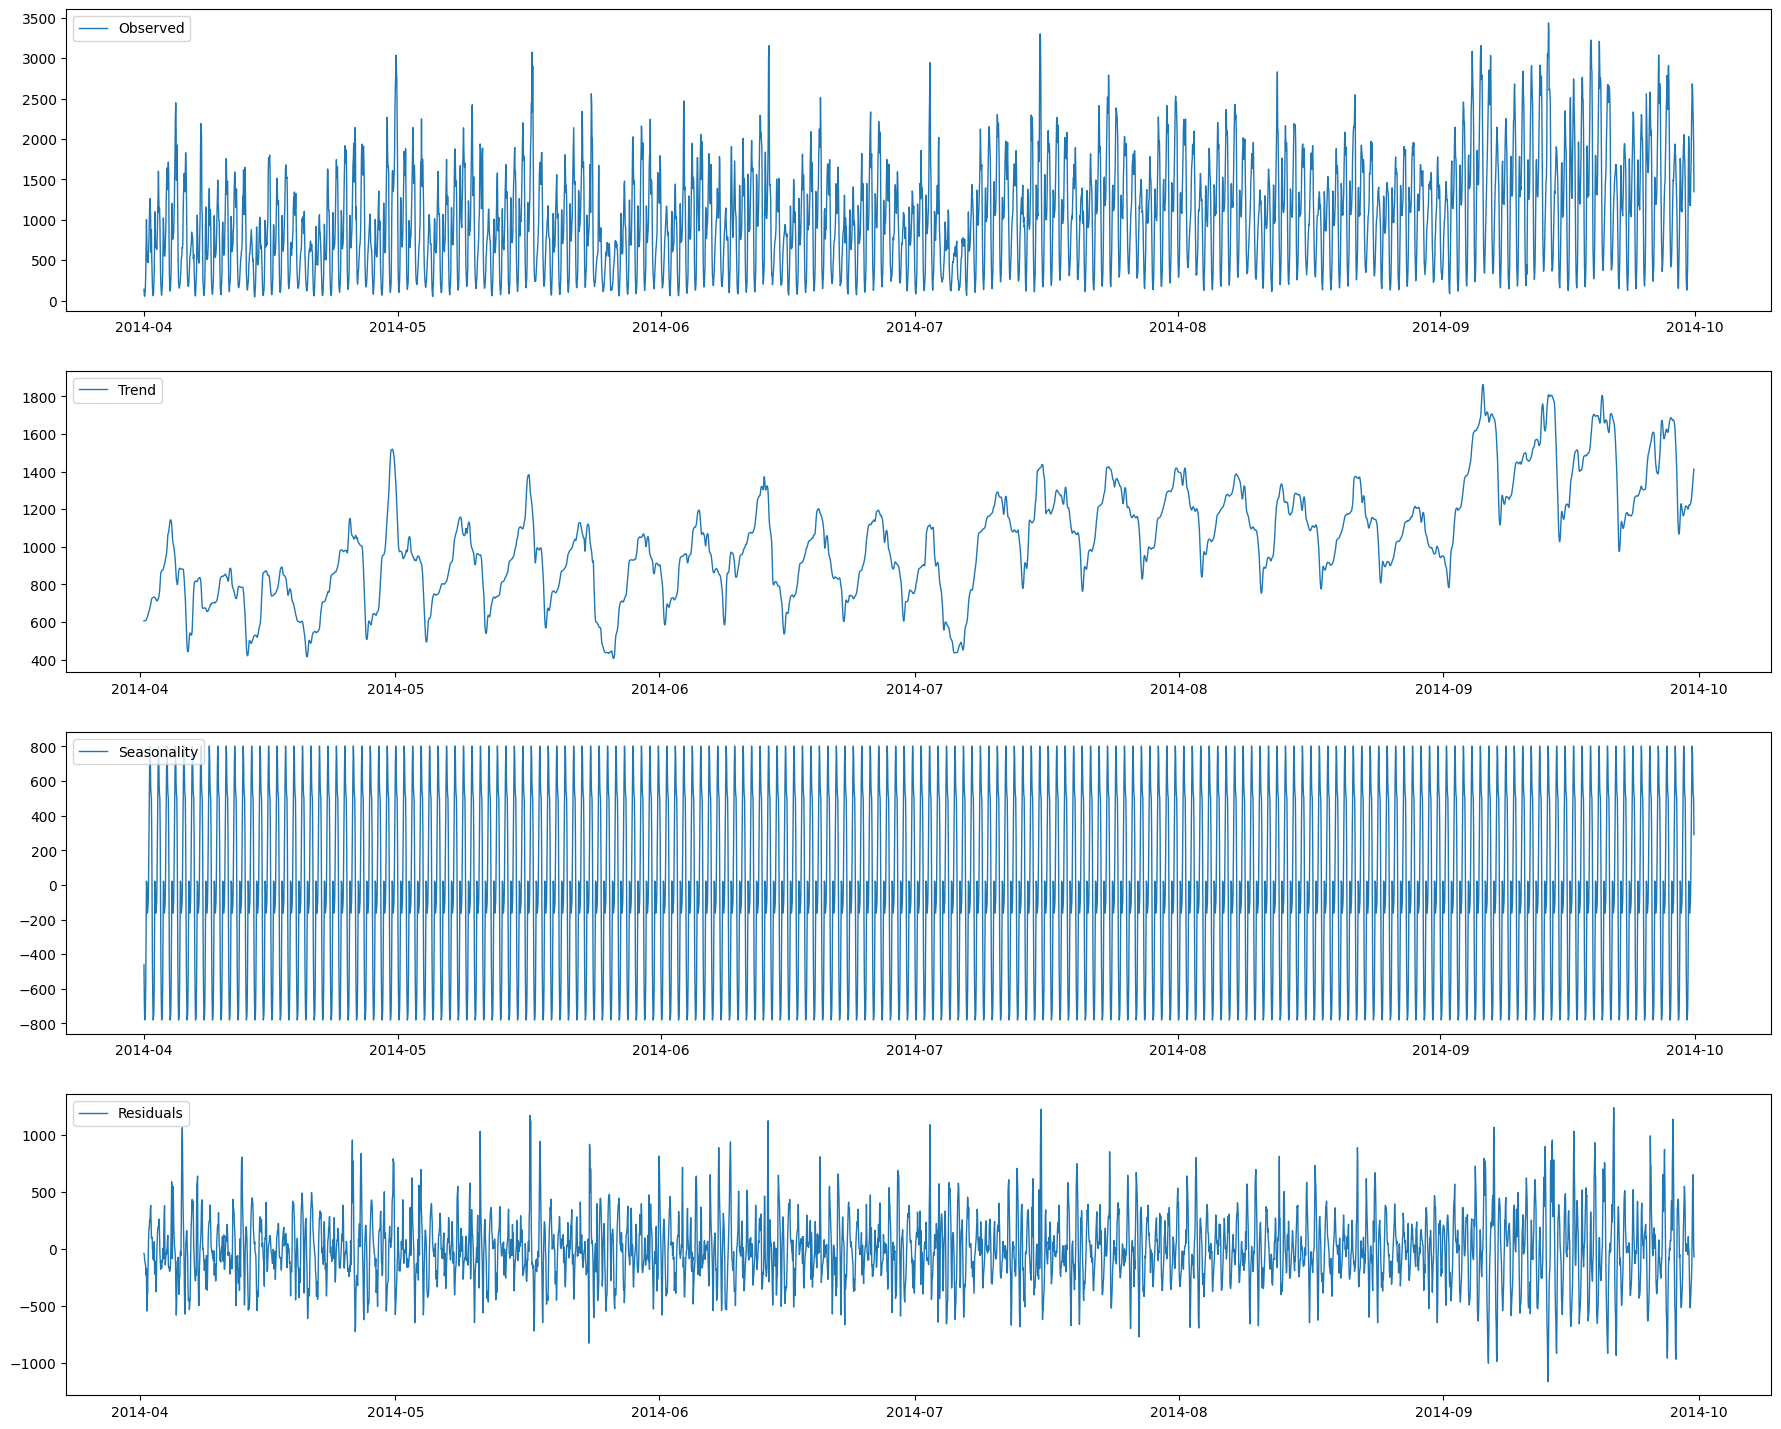

In [2]:
# --- 3. Exploratory Data Analysis (EDA) and Data Splitting ---

# Plot the series to visualize the overall trend
plt.figure(figsize=(28, 8))
plt.plot(data['Count'], linewidth=1, color='darkslateblue')
plt.title('Uber 2014 Trips: Hourly Counts')
plt.xticks(rotation=38, ha='right')
plt.show()

# Perform seasonal decomposition to identify trend, seasonality, and residuals
result = seasonal_decompose(data['Count'], model='add', period=24*1)
plt.figure(figsize=(22,18))
plt.subplot(4,1,1)
plt.plot(result.observed,label='Observed',lw=1)
plt.legend(loc='upper left')
plt.subplot(4,1,2)
plt.plot(result.trend,label='Trend',lw=1)
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Seasonality',lw=1)
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuals',lw=1)
plt.legend(loc='upper left')
plt.show()

# Based on the trend analysis from the PDF, we choose a custom cutoff date
cutoff_date = '2014-09-15 00:00:00'
uber2014_train = data.loc[:cutoff_date]
uber2014_test = data.loc[cutoff_date:]

# Define a function to create lagged features for time series forecasting
def create_lagged_features(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# Set the window size (e.g., 24 hours to look at the previous day's data)
window_size = 24

# Split data into training and test sets with lagged features
X_train, y_train = create_lagged_features(uber2014_train['Count'].values, window_size)

# Create test data by concatenating the end of the training set with the test set
test_data = np.concatenate([uber2014_train['Count'].values[-window_size:], uber2014_test['Count'].values])
X_test, y_test = create_lagged_features(test_data, window_size)



Fitting 5 folds for each of 8 candidates, totalling 40 fits
XGBoost MAPE: 9.16%
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Random Forest MAPE: 9.51%
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GBRT MAPE: 9.98%
Ensemble MAPE: 9.18%


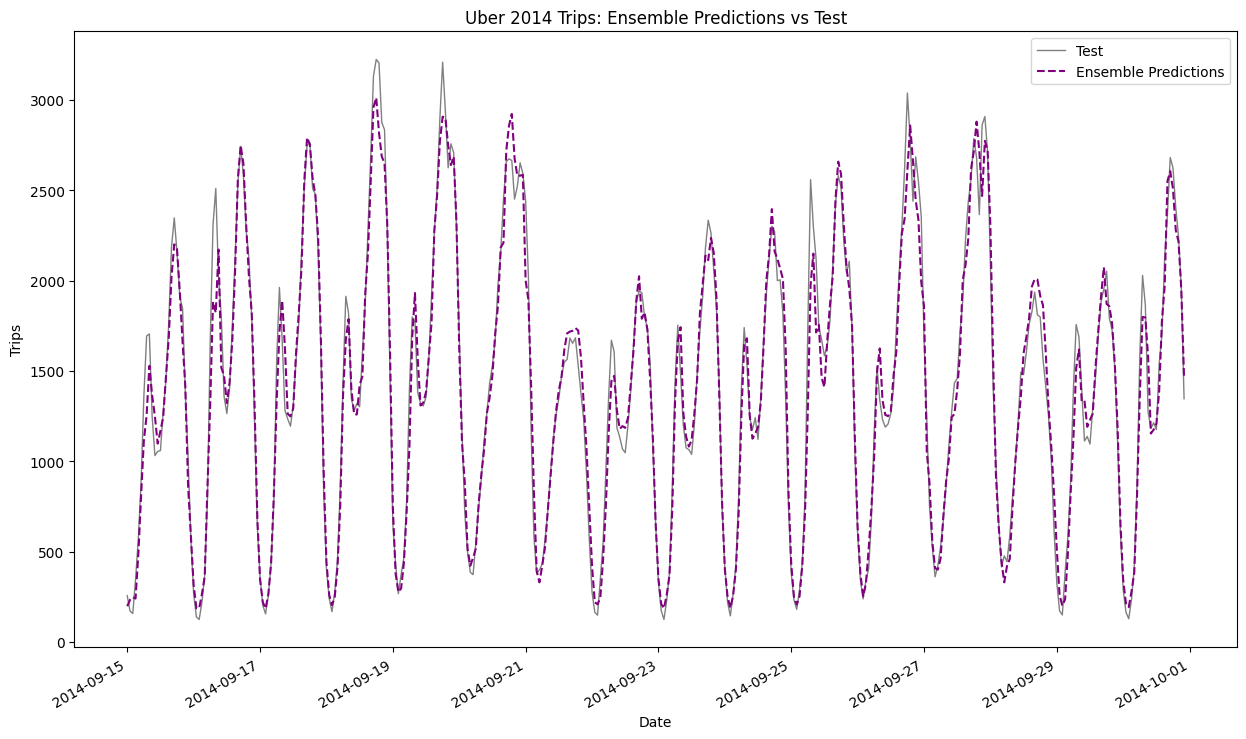

In [3]:
# --- 4. Model Training, Evaluation, and Ensemble ---
seed = 12345
tscv = TimeSeriesSplit(n_splits=5)

# --- XGBoost Model ---
# This code block trains and evaluates the XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=seed)
xgb_param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.1, 0.3]}
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid, cv=tscv, scoring='neg_mean_absolute_percentage_error', n_jobs=-1, verbose=1)
xgb_grid_search.fit(X_train, y_train)
xgb_predictions = xgb_grid_search.best_estimator_.predict(X_test)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_predictions)
print(f'XGBoost MAPE: {xgb_mape:.2%}')

# --- Random Forest Model ---
# This code block trains and evaluates the Random Forest model
rf_model = RandomForestRegressor(random_state=seed)
rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20]}
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=tscv, n_jobs=-1, scoring='neg_mean_absolute_percentage_error', verbose=1)
rf_grid_search.fit(X_train, y_train)
rf_predictions = rf_grid_search.best_estimator_.predict(X_test)
rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)
print(f'Random Forest MAPE: {rf_mape:.2%}')

# --- Gradient Boosted Regression Tree (GBRT) Model ---
# This code block trains and evaluates the GBRT model
gbr_model = GradientBoostingRegressor(random_state=seed)
gbr_param_grid = {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.3], 'max_depth': [3, 4]}
gbr_grid_search = GridSearchCV(estimator=gbr_model, param_grid=gbr_param_grid, cv=tscv, n_jobs=-1, scoring='neg_mean_absolute_percentage_error', verbose=1)
gbr_grid_search.fit(X_train, y_train)
gbr_predictions = gbr_grid_search.best_estimator_.predict(X_test)
gbr_mape = mean_absolute_percentage_error(y_test, gbr_predictions)
print(f'GBRT MAPE: {gbr_mape:.2%}')

# --- Ensemble Model ---
# This code block creates a weighted ensemble of the three models
# The weights are based on the original PDF's findings
weights = np.array([0.368, 0.322, 0.310])
ensemble_predictions = (weights[0] * xgb_predictions + weights[1] * rf_predictions + weights[2] * gbr_predictions)
ensemble_mape = mean_absolute_percentage_error(y_test, ensemble_predictions)
print(f'Ensemble MAPE: {ensemble_mape:.2%}')

# --- Visualization of Predictions ---
# This section plots the actual test data against the predictions of the ensemble model
plt.figure(figsize=(15, 8))
plt.plot(data.loc[cutoff_date:].index[:len(y_test)], y_test, label='Test', linewidth=1, color='gray')
plt.plot(data.loc[cutoff_date:].index[:len(y_test)], ensemble_predictions, label='Ensemble Predictions', linestyle='--', color='purple')
plt.title('Uber 2014 Trips: Ensemble Predictions vs Test')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.legend()
plt.xticks(rotation=30, ha='right')
plt.show()